In [181]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import astropy.units as u
from astropy.coordinates import SkyCoord

ROOT_DIR = Path(__doc__).resolve().parent.parent
location = ROOT_DIR / "data" / "field_lines" / "gs"

### Peanut

In [182]:
peanut = SkyCoord(ra='02h15m6.50s', dec='+42d32m17.42', frame='icrs', distance=3 * u.kpc)
peanut_ang_length = 4.60 * u.deg
peanut_ang_width = 0.45 * u.deg
peanut_angle = 13.8 * u.deg  # to RA axis, almost aligned with b=cst

peanut_gal = peanut.galactic
peanut_length = np.abs(peanut_ang_length.to_value(u.rad) * peanut.distance * np.cos(peanut_gal.l)).to(u.pc)
peanut_width = (peanut_ang_width.to_value(u.rad) * peanut.distance).to(u.pc)
print(f"Peanut size is {peanut_length:.1f} x {peanut_width:.1f}")

Peanut size is 181.7 pc x 23.6 pc


### Observer views

In [183]:
N_phi = 36
phi = np.linspace(1e-3, np.pi / 2 + 1e-3, N_phi, endpoint=True)

n_vectors = np.array([np.sin(phi), np.zeros_like(phi), np.cos(phi)]).T
n_vectors.shape

(36, 3)

In [184]:
# rotation matrices
ez = np.array([0, 0, 1]).T
a_nn = np.cross(n_vectors, ez)
a = a_nn / np.linalg.norm(a_nn, axis=-1, keepdims=True)  # axis of rotation

theta = np.arccos(n_vectors @ ez)  # rotation angle

### Load data

In [185]:
L = 300  # [pc]

counters = np.zeros([5, N_phi])

# for turb / reg ratio from the list below
etas = [0.1, 0.2, 0.5, 1.0, 2.0]

for j, eta in enumerate(etas):    
    print(f"{j}: ... eta = {eta:.1f} ...", end = ' ')
    
    counters_eta = np.zeros(N_phi)
    
    divisor = 0
    # for number of sample in (1 ... 20)
    for sn in range(1, 21):
                        
        divisor += 1
                
        print(sn, end = ' ')
        fl_file = location / f"eta{eta:.1f}" / f"lines_eta{eta:.1f}_s{sn}.npz"

        data = np.load(fl_file)

        step = 10

        s = data["s"][::step]
        lines_from_zero = data["lines"][::step]
        fields = data["fields"][::step]

        M = fields.shape[1]
        
        # projected
        r_sigma = lines_from_zero[..., None, :]- n_vectors[None, None, ...] * np.sum(lines_from_zero[..., None, :] * n_vectors[None, None, ...], axis=-1, keepdims=True)
        
        # rotations
        cross_a_r = np.cross(a, r_sigma)
        dot_a_r = np.sum(a[None, None, ...] * r_sigma, axis=-1, keepdims=True)
        
        rotated = r_sigma * np.cos(theta)[None, None, :, None] \
            + cross_a_r * np.sin(theta)[None, None, :, None] \
            + a[None, None, ...] * dot_a_r * (1 - np.cos(theta))[None, None, :, None]
            
        # Finally, count the lines inside
        x, y = rotated[..., 0], rotated[..., 1]
        
        x_in = (x > 0) * (x < peanut_length.value)
        y_in = (np.abs(y) < peanut_width.value / 2)
        xy_in = np.bool_(x_in * y_in + ~x_in)
        x_up = x > peanut_length.value  # peanut length
        
        counter = np.sum(np.bool_(np.prod(xy_in, axis=0) * np.sum(x_up, axis=0) * (len(x_up) > 0)), axis=0)
                
        counters_eta += counter
    
    counters[j] = counters_eta
    print('')
        
print("Fine!")

0: ... eta = 0.1 ... 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
1: ... eta = 0.2 ... 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
2: ... eta = 0.5 ... 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
3: ... eta = 1.0 ... 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
4: ... eta = 2.0 ... 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 
Fine!


In [186]:
counters[2]

array([   0.,    0.,    0.,    0.,    0.,    0.,    6.,   26.,   75.,
        150.,  219.,  318.,  442.,  556.,  686.,  821.,  969., 1109.,
       1248., 1388., 1498., 1655., 1760., 1868., 1991., 2091., 2186.,
       2270., 2346., 2427., 2480., 2541., 2580., 2600., 2615., 2624.])

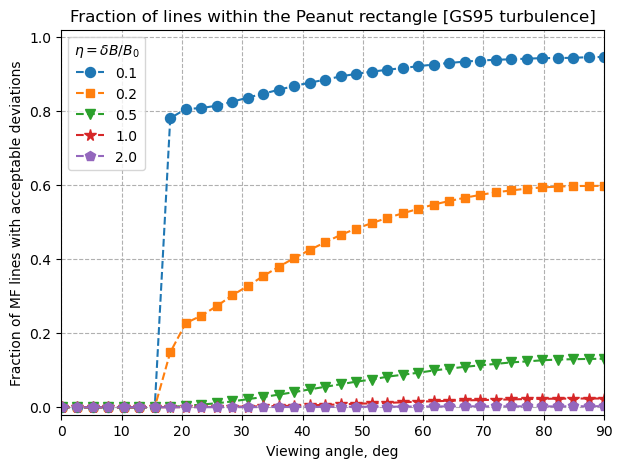

In [194]:
markers = ['o', 's', 'v', '*', 'p']
sizes = [1.2, 1, 1.1, 1.4, 1.2]

plt.figure(figsize=(7, 5))

for j in range(len(etas)):
    plt.plot(np.rad2deg(phi), counters[j] / M / divisor,
             marker=markers[j],
             markersize=6 * sizes[j],
             label=etas[j],
             linestyle='dashed')
    
plt.title("Fraction of lines within the Peanut rectangle [GS95 turbulence]")
    
plt.xlim(0, 90)
plt.xlabel('Viewing angle, deg')

plt.ylim(-0.02, 1.02)
# plt.yscale('log')
plt.ylabel('Fraction of MF lines with acceptable deviations')

plt.grid(linestyle='dashed')

plt.legend(title=r'$\eta = \delta B / B_0$')
# plt.savefig("straight-fraction.png", dpi=200)
plt.show()